# XGBoost Models for Volatility Forecasting

This notebook uses the MBO feature table built from raw CME MBO data to test whether recent market activity can help predict **future realized volatility** for CME futures contracts.

**Realized volatility** measures how much price actually moved over a given time window. A higher value means the market was more active or unstable. A lower value means the market was calmer.

This notebook focuses on two forecast horizons:
- the next **60 seconds**
- the next **300 seconds**

For each horizon, this notebook evaluates two XGBoost tasks:
- **classification**: predict whether future volatility will be a spike or not
- **regression**: predict the actual future volatility level

Overall, this notebook explores whether recent microstructure features contain useful predictive signal for short-horizon volatility forecasting.

#### Resources:
Official documentation for:
- XGBoost
- MLflow
- scikit-learn

# Setup

    - install packages
    - import libraries
    - create Spark session
    - load full feature table
    - create symbol list for modeling
    - create feature list for modeling

In [ ]:
# install packages for this notebook
!apt-get -qq install -y openjdk-17-jdk-headless
!pip install -q pyspark xgboost mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.0 MB/s eta 0:00:00


In [ ]:
# mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# standard library
import gc

# data tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# spark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# experiment tracking
import mlflow

# models
from xgboost import XGBClassifier, XGBRegressor

# regression metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# classification metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [ ]:
# set path to the full parquet feature table
# update this path for your local environment
TABLE_PATH = "/content/drive/MyDrive/CIS545_Group_Project/processed_data/mbo_features_table"


# create spark session
# update for your local environment
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("mbo_xgboost_models")
    .config("spark.driver.memory", "12g")
    .config("spark.sql.shuffle.partitions", "64")
    .getOrCreate()
)

# keep spark timestamps in UTC
spark.conf.set("spark.sql.session.timeZone", "UTC")

# load full feature table into spark
sdf = spark.read.parquet(TABLE_PATH)

# basic inspection
print("Number of rows:", sdf.count())
print("Number of columns:", len(sdf.columns))
print("Columns:")
print(sdf.columns)

Number of rows: 28681716
Number of columns: 47
Columns:
['session_date', 'second_bucket', 'n_events', 'n_add', 'n_cancel', 'n_modify', 'n_trade', 'n_fill', 'n_add_bid', 'n_add_ask', 'n_cancel_bid', 'n_cancel_ask', 'n_modify_bid', 'n_modify_ask', 'n_trade_buy', 'n_trade_sell', 'n_trade_none', 'trade_volume_buy', 'trade_volume_sell', 'trade_volume_none', 'trade_volume_total', 'fill_volume_total', 'n_bid', 'n_ask', 'bid_size', 'ask_size', 'avg_size', 'sum_size', 'max_size', 'last_price', 'filled_price', 'prev_price', 'log_return', 'rv_past_60', 'n_events_60', 'n_add_60', 'n_cancel_60', 'n_modify_60', 'n_trade_60', 'n_fill_60', 'sum_size_60', 'order_imbalance_60', 'size_imbalance_60', 'ret_std_60', 'rv_next_60', 'rv_next_300', 'symbol']


In [ ]:
# get symbols from spark table
symbol_list = sdf.select("symbol").distinct().orderBy("symbol").rdd.flatMap(lambda x: x).collect()

print("Symbols:")
print(symbol_list)

# add hour of day as a basic time feature since EDA showed strong intraday effects
sdf = sdf.withColumn("hour_utc", F.hour("second_bucket"))

# create features list based on EDA_advanced notebook
# EDA showed rv_past_60 and ret_std_60 were the strongest predictors,
# and several rolling 60-second activity features also showed useful signal
feature_cols = [
    "rv_past_60",
    "ret_std_60",
    "n_events_60",
    "n_add_60",
    "n_cancel_60",
    "n_modify_60",
    "n_trade_60",
    "n_fill_60",
    "sum_size_60",
    "order_imbalance_60",
    "size_imbalance_60",
    "n_events",
    "n_trade",
    "n_cancel",
    "trade_volume_total",
    "hour_utc",
]


Symbols:
['6E.c.0', 'BZ.c.0', 'CL.c.0', 'TN.c.0', 'UB.c.0', 'ZB.c.0', 'ZF.c.0', 'ZN.c.0', 'ZT.c.0']


# Persistence model

Persistence model: assume future volatility looks like recent volatility.

- EDA showed that recent realized volatility and future realized volatility are strongly correlated.

For each symbol, the volatility spike threshold is defined as the 90th percentile of the future realized volatility values in the training set. A spike is predicted whenever `rv_past_60` exceeds that threshold.

Two horizons are tested:
- **60 seconds**: past 60 seconds predicts next 60 seconds
- **300 seconds**: past 60 seconds predicts next 5 minutes

This provides a benchmark for the XGBoost models and helps show whether the MBO microstructure features add predictive signal beyond recent volatility alone.

In [ ]:
# track results for each contract
persistence_results = []

# create spark df with only the columns needed for the persistence model
persistence_columns = ["symbol", "session_date", "second_bucket", "rv_past_60", "rv_next_60", "rv_next_300"]
persistence_sdf = sdf.select(*persistence_columns)

# iterate over each symbol
for symbol in symbol_list:

    # filter to one symbol, keeping time order
    symbol_sdf = persistence_sdf.filter(F.col("symbol") == symbol).orderBy("session_date", "second_bucket")

    # convert to pandas df
    symbol_df = symbol_sdf.toPandas()

    # ensure second_bucket is in datetime format
    symbol_df["second_bucket"] = pd.to_datetime(symbol_df["second_bucket"])

    # chronologically split by session date: train (70%), validation (15%), and test (15%)
    dates = sorted(symbol_df["session_date"].unique())
    training_cutoff = int(len(dates) * 0.70)
    validation_cutoff = int(len(dates) * 0.85)

    train_dates = dates[:training_cutoff]
    validation_dates = dates[training_cutoff:validation_cutoff]
    test_dates = dates[validation_cutoff:]

    train_df = symbol_df[symbol_df["session_date"].isin(train_dates)].copy()
    validation_df = symbol_df[symbol_df["session_date"].isin(validation_dates)].copy()
    test_df = symbol_df[symbol_df["session_date"].isin(test_dates)].copy()

    # define volatility spike as the 90th percentile of the future target using only the training set
    vol_spike_threshold_60 = train_df["rv_next_60"].quantile(0.90)
    vol_spike_threshold_300 = train_df["rv_next_300"].quantile(0.90)

    # create test labels: 1 = future volatility spike, 0 = no spike
    test_df["vol_spike_60"] = (test_df["rv_next_60"] > vol_spike_threshold_60).astype(int)
    test_df["vol_spike_300"] = (test_df["rv_next_300"] > vol_spike_threshold_300).astype(int)

    # persistence model:
    # predict a future spike whenever current past volatility is already above the spike threshold
    test_pred_60 = (test_df["rv_past_60"] > vol_spike_threshold_60).astype(int)
    test_pred_300 = (test_df["rv_past_60"] > vol_spike_threshold_300).astype(int)

    # get test labels
    y_test_60 = test_df["vol_spike_60"]
    y_test_300 = test_df["vol_spike_300"]

    # evaluate the 60-second persistence model
    accuracy_60 = accuracy_score(y_test_60, test_pred_60)
    precision_60 = precision_score(y_test_60, test_pred_60)
    recall_60 = recall_score(y_test_60, test_pred_60)
    f1_60 = f1_score(y_test_60, test_pred_60)

    # evaluate the 300-second persistence model
    accuracy_300 = accuracy_score(y_test_300, test_pred_300)
    precision_300 = precision_score(y_test_300, test_pred_300)
    recall_300 = recall_score(y_test_300, test_pred_300)
    f1_300 = f1_score(y_test_300, test_pred_300)

    # save summary for this symbol
    persistence_results.append({
        "symbol": symbol,
        "volatility_spike_threshold_60": vol_spike_threshold_60,
        "test_spike_rate_60": y_test_60.mean(),
        "accuracy_60": accuracy_60,
        "precision_60": precision_60,
        "recall_60": recall_60,
        "f1_60": f1_60,
        "volatility_spike_threshold_300": vol_spike_threshold_300,
        "test_spike_rate_300": y_test_300.mean(),
        "accuracy_300": accuracy_300,
        "precision_300": precision_300,
        "recall_300": recall_300,
        "f1_300": f1_300
    })

    #print("complete:", symbol)

    # free memory before moving to the next symbol
    del symbol_sdf, symbol_df, train_df, validation_df, test_df
    del y_test_60, y_test_300, test_pred_60, test_pred_300
    gc.collect()

# put all results into dataframe for evaluation
persistence_results_df = pd.DataFrame(persistence_results).sort_values("f1_60", ascending=False).reset_index(drop=True)

persistence_results_df

,symbol,volatility_spike_threshold_60,test_spike_rate_60,accuracy_60,precision_60,recall_60,f1_60,volatility_spike_threshold_300,test_spike_rate_300,accuracy_300,precision_300,recall_300,f1_300
0,ZF.c.0,0.000123,0.276044,0.823136,0.679660,0.679605,0.679632,0.000267,0.270410,0.738728,0.968297,0.034936,0.067440
1,ZN.c.0,0.000309,0.229175,0.849690,0.672052,0.672093,0.672073,0.000674,0.218691,0.784050,0.980559,0.012789,0.025248
2,CL.c.0,0.000702,0.208395,0.823800,0.577165,0.577755,0.577460,0.001518,0.238030,0.773708,0.957455,0.051607,0.097936
3,TN.c.0,0.000192,0.281034,0.758998,0.571172,0.571584,0.571378,0.000425,0.220532,0.786263,0.887680,0.035273,0.067849
4,ZT.c.0,0.000053,0.223067,0.798282,0.547906,0.547297,0.547601,0.000106,0.220691,0.787717,0.931826,0.041105,0.078736
5,ZB.c.0,0.000379,0.272879,0.749870,0.541680,0.541718,0.541699,0.000836,0.202897,0.801314,0.889673,0.023691,0.046154
6,UB.c.0,0.000368,0.276958,0.737582,0.526258,0.526087,0.526173,0.000750,0.247191,0.763500,0.917230,0.047543,0.090400
7,BZ.c.0,0.000641,0.174553,0.798138,0.421868,0.422366,0.422117,0.001331,0.209140,0.803706,0.829390,0.077331,0.141471
8,6E.c.0,0.000136,0.036809,0.930609,0.057047,0.056997,0.057022,0.000304,0.081079,0.907028,0.111994,0.021169,0.035608


# XGBoost classifier: 60-second volatility spikes

Train one XGBoost classifier for each symbol.

For each symbol, the target is whether realized volatility over the next 60 seconds exceeds the 90th percentile of the training set.

Features come from the EDA-informed feature set. They include recent realized volatility, rolling 60-second activity counts, imbalance features, return dispersion, and hour of day.

A chronological split is used:
- 70% train
- 15% validation
- 15% test

The validation set is used for tuning:
- tree depth is searched over `[3, 4, 5]`
- probability threshold is searched from `0.10` to `0.55` in steps of `0.05`

The best model is chosen using validation **ROC-AUC**. ROC-AUC is useful here because it evaluates how well the model ranks spike vs non-spike cases across all possible thresholds.

The best threshold is chosen using validation **F1**. F1 is helpful because the spike classes are imbalanced, and it balances **precision** and **recall** when turning predicted probabilities into final class labels.

Most model settings stay fixed across symbols:
- `n_estimators = 800`: allows enough boosting rounds for the model to learn useful patterns
- `learning_rate = 0.05`: uses smaller boosting steps, which usually leads to more stable learning
- `subsample = 0.8`: each tree sees only part of the training data, which helps reduce overfitting
- `colsample_bytree = 0.8`: each tree uses only part of the feature set, which also helps reduce overfitting
- `early_stopping_rounds = 30`: stops training when validation performance no longer improves, which helps avoid fitting noise

One model is fit per symbol because EDA showed that volatility levels and behavior differ across contracts.

MLflow logs the settings and final metrics for each symbol.

In [ ]:
# add columns needed for filtering, ordering, and label creation to feature_cols
xgb_columns = ["symbol", "session_date", "second_bucket", "rv_next_60"] + feature_cols

# create spark df with selected columns
xgb_sdf_60 = sdf.select(*xgb_columns)

# track results for each symbol
results_60 = []

# store model objects for later evaluation
best_models_by_symbol_60 = {}
test_labels_by_symbol_60 = {}
test_prob_by_symbol_60 = {}
test_pred_by_symbol_60 = {}

# tuning grids, using wide threshold grid
max_depth_options = [3, 4, 5]
threshold_options = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]

# MLflow setup
mlflow.set_experiment("cis5450_xgb_classifier_60")

with mlflow.start_run(run_name="xgb_classifier_60_all_symbols"):

    # log settings
    mlflow.log_param("feature_cols", ", ".join(feature_cols))
    mlflow.log_param("max_depth_options", str(max_depth_options))
    mlflow.log_param("threshold_options", str(threshold_options))
    mlflow.log_param("target", "rv_next_60")

    # iterate over each symbol
    for symbol in symbol_list:

        # filter to one symbol and keep rows in time order
        symbol_sdf = xgb_sdf_60.filter(F.col("symbol") == symbol).orderBy("session_date", "second_bucket")

        # convert to pandas and ensure second_bucket in datetime format
        symbol_df = symbol_sdf.toPandas()
        symbol_df["second_bucket"] = pd.to_datetime(symbol_df["second_bucket"])

        # chronological split by session_date
        dates = sorted(symbol_df["session_date"].unique())
        training_cutoff = int(len(dates) * 0.70)
        validation_cutoff = int(len(dates) * 0.85)

        train_df = symbol_df[symbol_df["session_date"].isin(dates[:training_cutoff])].copy()
        validation_df = symbol_df[symbol_df["session_date"].isin(dates[training_cutoff:validation_cutoff])].copy()
        test_df = symbol_df[symbol_df["session_date"].isin(dates[validation_cutoff:])].copy()

        # define spike threshold from training set only
        vol_spike_threshold = train_df["rv_next_60"].quantile(0.90)

        # create binary labels: 1 = future volatility spike, 0 = no spike
        train_df["vol_spike_60"] = (train_df["rv_next_60"] > vol_spike_threshold).astype(int)
        validation_df["vol_spike_60"] = (validation_df["rv_next_60"] > vol_spike_threshold).astype(int)
        test_df["vol_spike_60"] = (test_df["rv_next_60"] > vol_spike_threshold).astype(int)

        # build X and y
        X_train = train_df[feature_cols]
        X_validation = validation_df[feature_cols]
        X_test = test_df[feature_cols]

        y_train = train_df["vol_spike_60"]
        y_validation = validation_df["vol_spike_60"]
        y_test = test_df["vol_spike_60"]

        # choose best model by validation ROC-AUC
        best_auc = -1
        best_model = None

        # fit model for each depth in depth grid
        for depth in max_depth_options:
            xgb_model = XGBClassifier(
                objective="binary:logistic",
                eval_metric="auc",
                n_estimators=800,
                max_depth=depth,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                early_stopping_rounds=30,
                random_state=42,
                n_jobs=-1
            )
            # use validation set for early stopping
            xgb_model.fit(
                X_train,
                y_train,
                eval_set=[(X_validation, y_validation)],
                verbose=False
            )
            # get predicted probabilities and ROC-AUC for the validation set
            validation_prob = xgb_model.predict_proba(X_validation)[:, 1]
            validation_auc = roc_auc_score(y_validation, validation_prob)

            # keep best model seen so far
            if validation_auc > best_auc:
                best_auc = validation_auc
                best_model = xgb_model

        # choose the probability threshold that gives the best validation F1
        best_threshold = 0.50
        best_f1 = -1

        # get validation probabilities from the best model
        best_validation_prob = best_model.predict_proba(X_validation)[:, 1]

        # try each threshold and calculate validation F1
        for threshold in threshold_options:
            validation_pred = (best_validation_prob >= threshold).astype(int)
            validation_f1 = f1_score(y_validation, validation_pred)

            # keep the threshold if it gives a better F1
            if validation_f1 > best_f1:
                best_f1 = validation_f1
                best_threshold = threshold

        # evaluate best model on test set
        test_prob = best_model.predict_proba(X_test)[:, 1]
        test_pred = (test_prob >= best_threshold).astype(int)
        accuracy = accuracy_score(y_test, test_pred)
        precision = precision_score(y_test, test_pred)
        recall = recall_score(y_test, test_pred)
        f1 = f1_score(y_test, test_pred)
        roc_auc = roc_auc_score(y_test, test_prob)

        # store model objects for later evaluation
        best_models_by_symbol_60[symbol] = best_model
        test_labels_by_symbol_60[symbol] = y_test.copy()
        test_prob_by_symbol_60[symbol] = test_prob.copy()
        test_pred_by_symbol_60[symbol] = test_pred.copy()

        # log metrics
        mlflow.log_metric(f"{symbol}_best_validation_auc", float(best_auc))
        mlflow.log_metric(f"{symbol}_accuracy", float(accuracy))
        mlflow.log_metric(f"{symbol}_precision", float(precision))
        mlflow.log_metric(f"{symbol}_recall", float(recall))
        mlflow.log_metric(f"{symbol}_f1", float(f1))
        mlflow.log_metric(f"{symbol}_roc_auc", float(roc_auc))

        # save summary row
        results_60.append({
            "symbol": symbol,
            "test_spike_rate": y_test.mean(),
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": roc_auc,
        })

        #print("complete:", symbol)

        # free memory
        del symbol_sdf, symbol_df, train_df, validation_df, test_df
        del X_train, X_validation, X_test, y_train, y_validation, y_test
        del validation_prob, best_validation_prob, test_prob, test_pred, xgb_model, best_model
        gc.collect()

# results dataframe sorted by F1
XGboost_classifier_results_df_60 = pd.DataFrame(results_60).sort_values("f1", ascending=False).reset_index(drop=True)

# save best symbol for later evaluation
best_symbol_60 = XGboost_classifier_results_df_60.loc[0, "symbol"]

XGboost_classifier_results_df_60

2026/04/04 23:01:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/04 23:01:26 INFO mlflow.store.db.utils: Updating database tables
2026/04/04 23:01:29 INFO mlflow.tracking.fluent: Experiment with name 'cis5450_xgb_classifier_60' does not exist. Creating a new experiment.


,symbol,test_spike_rate,accuracy,precision,recall,f1,roc_auc
0,ZF.c.0,0.276044,0.825257,0.642639,0.826671,0.723130,0.909781
1,ZN.c.0,0.229175,0.859361,0.660133,0.796293,0.721848,0.922933
2,TN.c.0,0.281034,0.758555,0.553506,0.728618,0.629104,0.837903
3,ZB.c.0,0.272879,0.750733,0.530668,0.748633,0.621082,0.834279
4,ZT.c.0,0.223067,0.813924,0.573495,0.646995,0.608032,0.855693
5,CL.c.0,0.208395,0.839016,0.623974,0.572525,0.597143,0.860547
6,UB.c.0,0.276958,0.720813,0.497299,0.740679,0.595065,0.804646
7,BZ.c.0,0.174553,0.737719,0.372334,0.732891,0.493800,0.818590
8,6E.c.0,0.036809,0.902113,0.114785,0.247213,0.156776,0.689447


# 60-Second classifier comparison

- Compare the persistence baseline and XGBoost classifier

In [ ]:
# get persistence model metrics
persistence_60 = persistence_results_df[["symbol", "test_spike_rate_60", "precision_60", "recall_60", "f1_60"]].copy()

# rename columns
persistence_60 = persistence_60.rename(columns={"test_spike_rate_60": "test_spike_rate", "precision_60": "persistence_precision", "recall_60": "persistence_recall", "f1_60": "persistence_f1"})

# get XGBoost metrics
xgb_60 = XGboost_classifier_results_df_60[["symbol", "accuracy", "precision", "recall", "f1", "roc_auc"]].copy()

# rename columns
xgb_60 = xgb_60.rename(columns={"accuracy": "xgb_accuracy", "precision": "xgb_precision", "recall": "xgb_recall", "f1": "xgb_f1", "roc_auc": "xgb_roc_auc"})

# merge persistence and XGBoost results by symbol
summary_60 = persistence_60.merge(xgb_60, on="symbol", how="inner")

# compute metric improvements
summary_60["precision_diff"] = summary_60["xgb_precision"] - summary_60["persistence_precision"]
summary_60["recall_diff"] = summary_60["xgb_recall"] - summary_60["persistence_recall"]
summary_60["f1_diff"] = summary_60["xgb_f1"] - summary_60["persistence_f1"]

# keep main columns and sort by F1 improvement
summary_60 = summary_60[["symbol", "test_spike_rate", "persistence_precision", "xgb_precision", "persistence_recall", "xgb_recall", "persistence_f1", "xgb_f1", "f1_diff", "xgb_accuracy", "xgb_roc_auc",]].sort_values("f1_diff", ascending=False).reset_index(drop=True)

summary_60

,symbol,test_spike_rate,persistence_precision,xgb_precision,persistence_recall,xgb_recall,persistence_f1,xgb_f1,f1_diff,xgb_accuracy,xgb_roc_auc
0,6E.c.0,0.036809,0.057047,0.114785,0.056997,0.247213,0.057022,0.156776,0.099754,0.902113,0.689447
1,ZB.c.0,0.272879,0.541680,0.530668,0.541718,0.748633,0.541699,0.621082,0.079383,0.750733,0.834279
2,BZ.c.0,0.174553,0.421868,0.372334,0.422366,0.732891,0.422117,0.493800,0.071683,0.737719,0.818590
3,UB.c.0,0.276958,0.526258,0.497299,0.526087,0.740679,0.526173,0.595065,0.068892,0.720813,0.804646
4,ZT.c.0,0.223067,0.547906,0.573495,0.547297,0.646995,0.547601,0.608032,0.060431,0.813924,0.855693
5,TN.c.0,0.281034,0.571172,0.553506,0.571584,0.728618,0.571378,0.629104,0.057726,0.758555,0.837903
6,ZN.c.0,0.229175,0.672052,0.660133,0.672093,0.796293,0.672073,0.721848,0.049776,0.859361,0.922933
7,ZF.c.0,0.276044,0.679660,0.642639,0.679605,0.826671,0.679632,0.723130,0.043498,0.825257,0.909781
8,CL.c.0,0.208395,0.577165,0.623974,0.577755,0.572525,0.577460,0.597143,0.019683,0.839016,0.860547


In [ ]:
# summary statistics across symbols for the 60-second classifier
summary_60_stats = summary_60[["test_spike_rate", "persistence_precision", "xgb_precision", "persistence_recall", "xgb_recall", "persistence_f1", "xgb_f1", "f1_diff", "xgb_accuracy", "xgb_roc_auc"]].agg(["mean", "min", "max"])

summary_60_stats

,test_spike_rate,persistence_precision,xgb_precision,persistence_recall,xgb_recall,persistence_f1,xgb_f1,f1_diff,xgb_accuracy,xgb_roc_auc
mean,0.219879,0.510534,0.507648,0.510611,0.671169,0.510573,0.571776,0.061203,0.800832,0.837091
min,0.036809,0.057047,0.114785,0.056997,0.247213,0.057022,0.156776,0.019683,0.720813,0.689447
max,0.281034,0.679660,0.660133,0.679605,0.826671,0.679632,0.723130,0.099754,0.902113,0.922933


# 60-Second classifier comparison summary

  The mean **test spike rate** was about **0.220**.
- Since about **22%** of test rows were spikes, this is an imbalanced classification problem.
  - Therefore, **F1** is the main evaluation metric.

We report **precision**, **recall**, **F1**, **accuracy**, and **ROC-AUC**.
  - **Precision** is the share of predicted spikes that were real spikes.
  - **Recall** is the share of real spikes the model caught.
  - **F1** combines precision and recall, so it is the main comparison metric here.
  - **ROC-AUC** shows how well the model ranks spikes above non-spikes across thresholds.
  - **Accuracy** is not the main focus because a model can score well by mostly predicting no-spike.

On average, XGBoost had:
  - slightly lower **precision** than persistence (**0.508** vs **0.511**)
  - clearly higher **recall** (**0.671** vs **0.511**)
  - higher **F1** (**0.572** vs **0.511**)
  - mean **ROC-AUC** of about **0.837**
  - mean **accuracy** of about **0.801**

The average **F1 improvement** was about **0.061** across symbols.
  - So XGBoost improved the overall precision-recall balance.

- The main gain came from higher **recall**.
  - Essentially, XGBoost caught more real spikes.
- Average precision did not improve.

Findings are consistent with the EDA.
  - Recent realized volatility looked like the strongest single predictor.
  - So the persistence baseline was already fairly strong at the 60-second horizon.
  - That helps explain why the gains from XGBoost were positive but still modest.

Overall takeaway:
  - XGBoost performed better than persistence on average
  - the gains were modest but consistent
  - the main benefit was catching more real spikes

# XGBoost classifier: 300-second volatility spikes

Train one XGBoost classifier for each symbol.

For each symbol, the target is whether realized volatility over the next 300 seconds exceeds the 90th percentile of the training set.

Features come from the EDA-informed feature set. They include recent realized volatility, rolling 60-second activity counts, imbalance features, return dispersion, and hour of day.

A chronological split is used:
- 70% train
- 15% validation
- 15% test

The validation set is used for tuning:
- tree depth is searched over `[3, 4, 5]`
- probability threshold is searched from `0.10` to `0.55` in steps of `0.05`

The best model is chosen using validation **ROC-AUC**. ROC-AUC is useful here because it measures how well the model separates spike vs non-spike cases across thresholds.

The best threshold is chosen using validation **F1**. F1 is helpful because the spike classes are imbalanced, and it balances **precision** and **recall** when converting predicted probabilities into final class labels.

Most model settings stay fixed across symbols:
- `n_estimators = 800`: allows enough boosting rounds for the model to learn useful patterns
- `learning_rate = 0.05`: uses smaller boosting steps, which usually leads to more stable learning
- `subsample = 0.8`: each tree sees only part of the training data, which helps reduce overfitting
- `colsample_bytree = 0.8`: each tree uses only part of the feature set, which also helps reduce overfitting
- `early_stopping_rounds = 30`: stops training when validation performance no longer improves, which helps avoid fitting noise

One model is fit per symbol because EDA showed that volatility levels and behavior differ across contracts.

MLflow logs the settings and final metrics for each symbol.

In [ ]:
# add columns needed for filtering, ordering, and label creation to feature_cols
xgb_columns = ["symbol", "session_date", "second_bucket", "rv_next_300"] + feature_cols

# create spark df with selected columns
xgb_sdf_300 = sdf.select(*xgb_columns)

# track results for each symbol
results_300 = []

# store model objects for later evaluation
best_models_by_symbol_300 = {}
test_labels_by_symbol_300 = {}
test_prob_by_symbol_300 = {}
test_pred_by_symbol_300 = {}

# tuning grids, using wide threshold grid
max_depth_options = [3, 4, 5]
threshold_options = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]

# MLflow setup
mlflow.set_experiment("cis5450_xgb_classifier_300")

with mlflow.start_run(run_name="xgb_classifier_300_all_symbols"):

    # log settings
    mlflow.log_param("feature_cols", ", ".join(feature_cols))
    mlflow.log_param("max_depth_options", str(max_depth_options))
    mlflow.log_param("threshold_options", str(threshold_options))
    mlflow.log_param("target", "rv_next_300")

    # iterate over each symbol
    for symbol in symbol_list:

        # filter to one symbol and keep rows in time order
        symbol_sdf = xgb_sdf_300.filter(F.col("symbol") == symbol).orderBy("session_date", "second_bucket")

        # convert to pandas and ensure second bucket in datetime format
        symbol_df = symbol_sdf.toPandas()
        symbol_df["second_bucket"] = pd.to_datetime(symbol_df["second_bucket"])

        # chronological split by session_date
        dates = sorted(symbol_df["session_date"].unique())
        training_cutoff = int(len(dates) * 0.70)
        validation_cutoff = int(len(dates) * 0.85)

        train_df = symbol_df[symbol_df["session_date"].isin(dates[:training_cutoff])].copy()
        validation_df = symbol_df[symbol_df["session_date"].isin(dates[training_cutoff:validation_cutoff])].copy()
        test_df = symbol_df[symbol_df["session_date"].isin(dates[validation_cutoff:])].copy()

        # define spike threshold from training set
        vol_spike_threshold = train_df["rv_next_300"].quantile(0.90)

        # create binary labels: 1 = future volatility spike, 0 = no spike
        train_df["vol_spike_300"] = (train_df["rv_next_300"] > vol_spike_threshold).astype(int)
        validation_df["vol_spike_300"] = (validation_df["rv_next_300"] > vol_spike_threshold).astype(int)
        test_df["vol_spike_300"] = (test_df["rv_next_300"] > vol_spike_threshold).astype(int)

        # build X and y
        X_train = train_df[feature_cols]
        X_validation = validation_df[feature_cols]
        X_test = test_df[feature_cols]

        y_train = train_df["vol_spike_300"]
        y_validation = validation_df["vol_spike_300"]
        y_test = test_df["vol_spike_300"]

        # choose best model by validation ROC-AUC
        best_auc = -1
        best_model = None

        # fit model for each depth in depth grid
        for depth in max_depth_options:
            xgb_model = XGBClassifier(
                objective="binary:logistic",
                eval_metric="auc",
                n_estimators=800,
                max_depth=depth,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                early_stopping_rounds=30,
                random_state=42,
                n_jobs=-1
            )
            # use validation set for early stopping
            xgb_model.fit(
                X_train,
                y_train,
                eval_set=[(X_validation, y_validation)],
                verbose=False
            )
            # get predicted probabilities and ROC-AUC for the validation set
            validation_prob = xgb_model.predict_proba(X_validation)[:, 1]
            validation_auc = roc_auc_score(y_validation, validation_prob)

            # keep best model so far
            if validation_auc > best_auc:
                best_auc = validation_auc
                best_model = xgb_model

        # choose probability threshold that gives best validation F1
        best_threshold = 0.50
        best_f1 = -1

        # get validation probabilities from the best model
        best_validation_prob = best_model.predict_proba(X_validation)[:, 1]

        # try each threshold and calculate validation F1
        for threshold in threshold_options:
            validation_pred = (best_validation_prob >= threshold).astype(int)
            validation_f1 = f1_score(y_validation, validation_pred)

            # keep the threshold if it gives a better F1
            if validation_f1 > best_f1:
                best_f1 = validation_f1
                best_threshold = threshold

        # evaluate best model on test set
        test_prob = best_model.predict_proba(X_test)[:, 1]
        test_pred = (test_prob >= best_threshold).astype(int)
        accuracy = accuracy_score(y_test, test_pred)
        precision = precision_score(y_test, test_pred)
        recall = recall_score(y_test, test_pred)
        f1 = f1_score(y_test, test_pred)
        roc_auc = roc_auc_score(y_test, test_prob)

        # store model objects for later evaluation
        best_models_by_symbol_300[symbol] = best_model
        test_labels_by_symbol_300[symbol] = y_test.copy()
        test_prob_by_symbol_300[symbol] = test_prob.copy()
        test_pred_by_symbol_300[symbol] = test_pred.copy()

        # log metrics
        mlflow.log_metric(f"{symbol}_best_validation_auc", float(best_auc))
        mlflow.log_metric(f"{symbol}_accuracy", float(accuracy))
        mlflow.log_metric(f"{symbol}_precision", float(precision))
        mlflow.log_metric(f"{symbol}_recall", float(recall))
        mlflow.log_metric(f"{symbol}_f1", float(f1))
        mlflow.log_metric(f"{symbol}_roc_auc", float(roc_auc))

        # save summary row
        results_300.append({
            "symbol": symbol,
            "test_spike_rate": y_test.mean(),
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": roc_auc,
        })

        #print("complete:", symbol)

        # free memory
        del symbol_sdf, symbol_df, train_df, validation_df, test_df
        del X_train, X_validation, X_test, y_train, y_validation, y_test
        del validation_prob, best_validation_prob, test_prob, test_pred, xgb_model, best_model
        gc.collect()

# results df sorted by F1
XGboost_classifier_results_df_300 = pd.DataFrame(results_300).sort_values("f1", ascending=False).reset_index(drop=True)

# best symbol for later evaluation
best_symbol_300 = XGboost_classifier_results_df_300.loc[0, "symbol"]

XGboost_classifier_results_df_300

2026/04/04 23:58:26 INFO mlflow.tracking.fluent: Experiment with name 'cis5450_xgb_classifier_300' does not exist. Creating a new experiment.


,symbol,test_spike_rate,accuracy,precision,recall,f1,roc_auc
0,ZF.c.0,0.270410,0.874021,0.735276,0.834603,0.781797,0.942540
1,ZN.c.0,0.218691,0.890966,0.706496,0.857778,0.774822,0.953155
2,ZT.c.0,0.220691,0.857595,0.646105,0.784348,0.708546,0.916716
3,UB.c.0,0.247191,0.823427,0.627894,0.701278,0.662560,0.882396
4,TN.c.0,0.220532,0.815085,0.562189,0.729999,0.635198,0.881197
5,ZB.c.0,0.202897,0.813905,0.527973,0.781482,0.630188,0.887206
6,CL.c.0,0.238030,0.842765,0.724095,0.548390,0.624111,0.866644
7,BZ.c.0,0.209140,0.815491,0.546278,0.695106,0.611770,0.857964
8,6E.c.0,0.081079,0.799588,0.180591,0.416074,0.251864,0.706230


# 300-Second classifier comparison

- Compare the persistence baseline and XGBoost classifier

In [ ]:
# get persistence model metrics
persistence_300 = persistence_results_df[["symbol", "test_spike_rate_300", "precision_300", "recall_300", "f1_300"]].copy()

# rename columns
persistence_300 = persistence_300.rename(columns={"test_spike_rate_300": "test_spike_rate", "precision_300": "persistence_precision", "recall_300": "persistence_recall", "f1_300": "persistence_f1"})

# get XGBoost metrics
xgb_300 = XGboost_classifier_results_df_300[["symbol", "accuracy", "precision", "recall", "f1", "roc_auc"]].copy()

# rename columns
xgb_300 = xgb_300.rename(columns={ "accuracy": "xgb_accuracy", "precision": "xgb_precision", "recall": "xgb_recall", "f1": "xgb_f1", "roc_auc": "xgb_roc_auc"})

# merge persistence and XGBoost results by symbol
summary_300 = persistence_300.merge(xgb_300, on="symbol", how="inner")

# compute metric improvements
summary_300["precision_diff"] = summary_300["xgb_precision"] - summary_300["persistence_precision"]
summary_300["recall_diff"] = summary_300["xgb_recall"] - summary_300["persistence_recall"]
summary_300["f1_diff"] = summary_300["xgb_f1"] - summary_300["persistence_f1"]

# keep main columns and sort by F1 improvement
summary_300 = summary_300[["symbol", "test_spike_rate", "persistence_precision", "xgb_precision", "persistence_recall","xgb_recall", "persistence_f1", "xgb_f1", "f1_diff", "xgb_accuracy", "xgb_roc_auc",]].sort_values("f1_diff", ascending=False).reset_index(drop=True)

summary_300

,symbol,test_spike_rate,persistence_precision,xgb_precision,persistence_recall,xgb_recall,persistence_f1,xgb_f1,f1_diff,xgb_accuracy,xgb_roc_auc
0,ZN.c.0,0.218691,0.980559,0.706496,0.012789,0.857778,0.025248,0.774822,0.749573,0.890966,0.953155
1,ZF.c.0,0.270410,0.968297,0.735276,0.034936,0.834603,0.067440,0.781797,0.714358,0.874021,0.942540
2,ZT.c.0,0.220691,0.931826,0.646105,0.041105,0.784348,0.078736,0.708546,0.629810,0.857595,0.916716
3,ZB.c.0,0.202897,0.889673,0.527973,0.023691,0.781482,0.046154,0.630188,0.584034,0.813905,0.887206
4,UB.c.0,0.247191,0.917230,0.627894,0.047543,0.701278,0.090400,0.662560,0.572161,0.823427,0.882396
5,TN.c.0,0.220532,0.887680,0.562189,0.035273,0.729999,0.067849,0.635198,0.567348,0.815085,0.881197
6,CL.c.0,0.238030,0.957455,0.724095,0.051607,0.548390,0.097936,0.624111,0.526175,0.842765,0.866644
7,BZ.c.0,0.209140,0.829390,0.546278,0.077331,0.695106,0.141471,0.611770,0.470299,0.815491,0.857964
8,6E.c.0,0.081079,0.111994,0.180591,0.021169,0.416074,0.035608,0.251864,0.216256,0.799588,0.706230


In [ ]:
# summary statistics across symbols for the 300-second classifier
summary_300_stats = summary_300[[ "test_spike_rate", "persistence_precision", "xgb_precision", "persistence_recall","xgb_recall", "persistence_f1", "xgb_f1", "f1_diff", "xgb_accuracy", "xgb_roc_auc",]].agg(["mean", "min", "max"])

summary_300_stats

,test_spike_rate,persistence_precision,xgb_precision,persistence_recall,xgb_recall,persistence_f1,xgb_f1,f1_diff,xgb_accuracy,xgb_roc_auc
mean,0.212073,0.830456,0.584100,0.038383,0.705451,0.072316,0.631206,0.558891,0.836983,0.877116
min,0.081079,0.111994,0.180591,0.012789,0.416074,0.025248,0.251864,0.216256,0.799588,0.706230
max,0.270410,0.980559,0.735276,0.077331,0.857778,0.141471,0.781797,0.749573,0.890966,0.953155


# 300-Second classifier comparison summary

The mean **test spike rate** was about **0.212**.
- So about **21%** of test rows were spikes, meaning this is still an imbalanced classification problem.

On average, XGBoost had:
  - lower **precision** than persistence (**0.584** vs **0.830**)
  - much higher **recall** (**0.705** vs **0.038**)
  - much higher **F1** (**0.631** vs **0.072**)
  - mean **ROC-AUC** of about **0.877**
  - mean **accuracy** of about **0.837**

The average **F1 improvement** was about **0.559** across symbols.
- So XGBoost improved the overall precision-recall balance by a wide margin.

- The persistence model became much weaker at the 300-second horizon.
- It relied on a single 60-second backward-looking volatility signal to classify a spike 300 seconds ahead.

As a result, persistence predicted spikes much less effectively at this longer horizon.

- XGBoost was less limited by that issue.
- It combined multiple recent signals instead of relying on one threshold rule.
- The broader **MBO microstructure feature set** seems to transfer better to the longer horizon.
- Rolling activity, imbalance, and return-dispersion features appear to add useful signal.

Overall takeaway:
  - XGBoost performed much better than persistence on average
  - the gains were much larger than in the 60-second case
  - the broader microstructure feature set mattered more for the 300-second spike task

# Confusion matrices for the top 60-second and 300-second classifiers
- using the top-performing symbol for each horizon

- Confusion matrices summarize correct classifications and model errors.


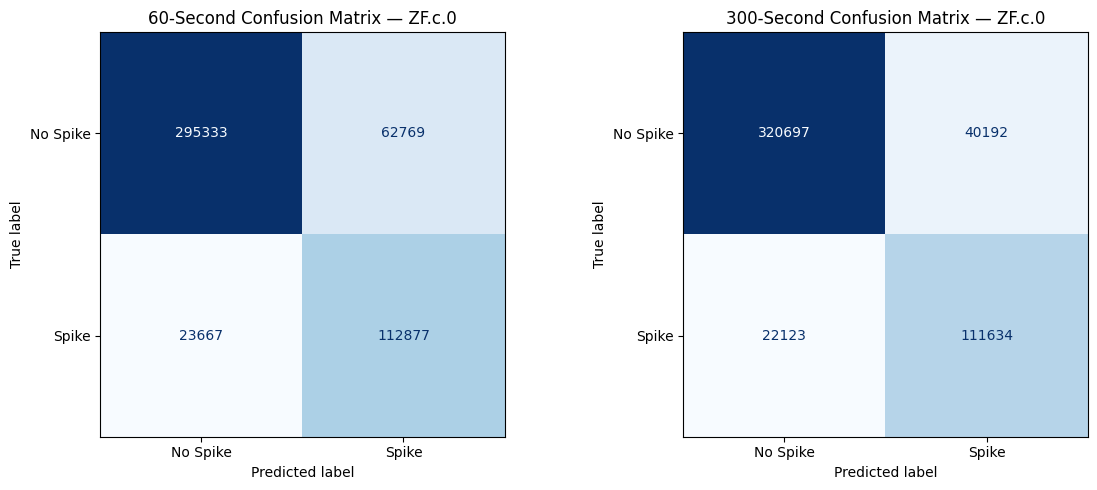

In [ ]:
# choose any symbol you want to analyze - we will look at best performer for each time-horizon
symbol_60 = best_symbol_60
symbol_300 = best_symbol_300

# create confusion matrices from the saved evaluation dictionaries
cm_60 = confusion_matrix(test_labels_by_symbol_60[symbol_60], test_pred_by_symbol_60[symbol_60])
cm_300 = confusion_matrix(test_labels_by_symbol_300[symbol_300], test_pred_by_symbol_300[symbol_300])

# plot them side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_60 = ConfusionMatrixDisplay(confusion_matrix=cm_60, display_labels=["No Spike", "Spike"])
disp_60.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"60-Second Confusion Matrix — {symbol_60}")

disp_300 = ConfusionMatrixDisplay(confusion_matrix=cm_300, display_labels=["No Spike", "Spike"])
disp_300.plot(ax=axes[1], cmap="Blues", colorbar=False, values_format="d")
axes[1].set_title(f"300-Second Confusion Matrix — {symbol_300}")

plt.tight_layout()
plt.show()

# Confusion matrix interpretation for ZF.c.0

- Both classifiers identify a large number of true spike periods:
  - **60-second:** 112,877 true positives
  - **300-second:** 111,634 true positives

- The main difference is in the false positives:
  - **60-second:** 62,769 false positives
  - **300-second:** 40,192 false positives

- The 300-second classifier also has slightly fewer false negatives:
  - **60-second:** 23,667 missed spikes
  - **300-second:** 22,123 missed spikes

- Overall takeaway:
  - both models catch many real volatility spikes
  - the 300-second classifier makes fewer mistakes overall
  - the 60-second classifier is still useful, but it creates more false alarms

# ROC curves for the top 60-second and 300-second classifiers

- using the top-performing symbol for each horizon

- ROC curves show how well the classifier ranks spike periods above non-spike periods across all possible probability thresholds.
- A curve closer to the top-left corner indicates better performance.
- **AUC** summarizes that ranking performance in a single number.

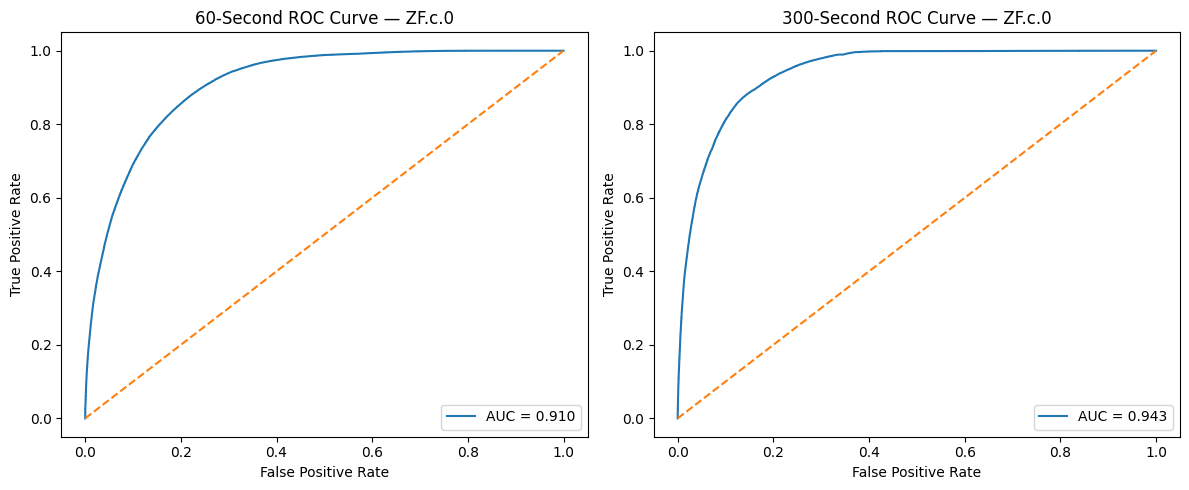

In [ ]:
# choose any symbols you want to analyze - we will look at best performer for each time-horizon
symbol_60 = best_symbol_60
symbol_300 = best_symbol_300

# get the saved test labels and predicted probabilities
y_test_60 = test_labels_by_symbol_60[symbol_60]
test_prob_60 = test_prob_by_symbol_60[symbol_60]

y_test_300 = test_labels_by_symbol_300[symbol_300]
test_prob_300 = test_prob_by_symbol_300[symbol_300]

# compute ROC and AUC for the 60-second classifier
fpr_60, tpr_60, _ = roc_curve(y_test_60, test_prob_60)
roc_auc_60 = auc(fpr_60, tpr_60)

# compute ROC and AUC for the 300-second classifier
fpr_300, tpr_300, _ = roc_curve(y_test_300, test_prob_300)
roc_auc_300 = auc(fpr_300, tpr_300)

# plot the two ROC curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 60-second ROC curve
axes[0].plot(fpr_60, tpr_60, label=f"AUC = {roc_auc_60:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title(f"60-Second ROC Curve — {symbol_60}")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# 300-second ROC curve
axes[1].plot(fpr_300, tpr_300, label=f"AUC = {roc_auc_300:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title(f"300-Second ROC Curve — {symbol_300}")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# ROC curve interpretation for ZF.c.0

Both ROC curves are well above the diagonal line, so both classifiers do a good job separating spike periods from non-spike periods.
- The **60-second** classifier has an AUC of about **0.910**.
- The **300-second** classifier has an AUC of about **0.943**.

Both values are strong.
- The 300-second classifier does a little better overall, with a curve that stays closer to the top-left corner.

Overall takeaway:
  - both models rank spike periods well
  - the 300-second classifier shows slightly stronger performance

# Feature importance for the top 60-second and 300-second classifiers


- using the top-performing symbol for each horizon

- Feature importance shows which recent market features are most useful to the XGBoost classifiers.


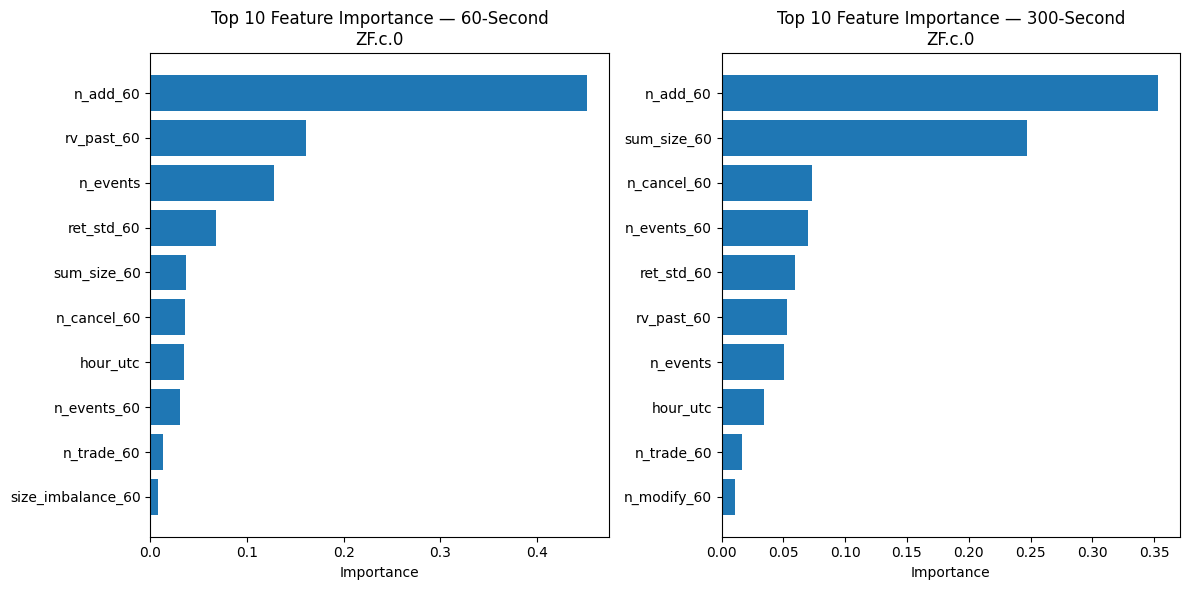

In [ ]:

# choose the best symbol for each horizon - we will look at best performer for each time-horizon
symbol_60 = best_symbol_60
symbol_300 = best_symbol_300

# get the saved best models
model_60 = best_models_by_symbol_60[symbol_60]
model_300 = best_models_by_symbol_300[symbol_300]

# build feature importance tables
importance_60 = pd.DataFrame({"feature": feature_cols, "importance": model_60.feature_importances_}).sort_values("importance", ascending=False)

importance_300 = pd.DataFrame({"feature": feature_cols, "importance": model_300.feature_importances_}).sort_values("importance", ascending=False)

# keep top 10 features
top_10_60 = importance_60.head(10).sort_values("importance", ascending=True)
top_10_300 = importance_300.head(10).sort_values("importance", ascending=True)

# plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].barh(top_10_60["feature"], top_10_60["importance"])
axes[0].set_title(f"Top 10 Feature Importance — 60-Second\n{symbol_60}")
axes[0].set_xlabel("Importance")

axes[1].barh(top_10_300["feature"], top_10_300["importance"])
axes[1].set_title(f"Top 10 Feature Importance — 300-Second\n{symbol_300}")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

# Feature importance interpretation for ZF.c.0

In both horizons, **`n_add_60`** is the most important feature by a wide margin.
- This suggests that recent order submission activity is a major signal for future volatility spikes.

The **60-second** classifier leans more on recent volatility features such as **`rv_past_60`** and **`ret_std_60`**.
- This fits the short-horizon story, where the most recent volatility conditions still matter a lot.

The **300-second** classifier appears to rely more on broader activity and size features such as **`sum_size_60`**, **`n_cancel_60`**, and **`n_events_60`**.
- This suggests that longer-horizon spike prediction appears to rely more on overall market activity, not just recent volatility alone.

Overall takeaway:
  - recent order-flow activity matters at both horizons
  - the 60-second model stays closer to recent volatility
  - the 300-second model appears to use a broader microstructure signal

# How could a volatility spike signal be used?

- A short-horizon volatility spike classifier is most useful as a **caution signal**, not a directional trading signal.
- The model predicts whether near-term volatility is likely to rise, not whether price will go up or down.

- Some realistic use cases are:
  - **execution timing:** a trader could slow, pause, or split a large order when a volatility spike is predicted. Large orders can take time to work through the market, and trading during a spike can cause slippage (filling at worse prices as the market moves away). A short pause during predicted turbulence can reduce total trading costs.
  - **market making:** a market maker could widen spreads or reduce quote size during predicted spike periods. Market makers earn small profits on many trades by quoting both a buy and a sell price, but a sudden price move can leave those quotes stale and cause losses. Widening spreads ahead of a spike is a simple way to stay protected when the market is expected to move fast.
  - **short-horizon risk management:** a risk manager could use the signal as an early warning that near-term volatility may rise. Most risk systems react to volatility that has already happened, so a forward-looking signal gives a small amount of lead time to tighten position limits or review exposures before conditions become more unstable.

- These use cases fit the classifier especially well because they depend on a simple decision: whether to become more defensive or not.
- The **300-second classifier** is probably the most practical version for many of these use cases because it gives a little more reaction time than the 60-second version.

- Overall takeaway:
  - the classifier is most useful as a **defensive signal**
  - the signal can be used to avoid a bad trading environment rather than predicting price direction
  - the 300-second horizon is probably the most practical version for real use

In [ ]:
# delete saved classifier objects before starting the regressor section
del best_models_by_symbol_60
del test_labels_by_symbol_60
del test_prob_by_symbol_60
del test_pred_by_symbol_60
del best_models_by_symbol_300
del test_labels_by_symbol_300
del test_prob_by_symbol_300
del test_pred_by_symbol_300
del XGboost_classifier_results_df_60
del XGboost_classifier_results_df_300
del best_symbol_60
del best_symbol_300

gc.collect()

6387

# XGBoost regressor: 60-second future volatility

Train a XGBoost regressor for each symbol.

For each symbol, the target is **`rv_next_60`**, which is the level of realized volatility over the next 60 seconds.

Features come from the EDA-informed feature set. They include recent realized volatility, rolling 60-second activity counts, imbalance features, return dispersion, and hour of day.

A chronological split is used:
- 70% train
- 15% validation
- 15% test

The target is modeled on the **`log1p`** scale because future realized volatility is strongly right-skewed. This helps reduce the influence of extreme values. Predictions are then converted back to the raw scale before final evaluation.

The validation set is used for tuning:
- tree depth is searched over `[3, 4, 5]`

The best model is chosen using validation **RMSE**. RMSE is useful here because it measures the typical size of prediction errors, while giving more weight to larger mistakes. This makes it a good fit for a volatility forecasting task, where large misses matter more.

Most model settings stay fixed across symbols:
- `n_estimators = 800`: allows enough boosting rounds for the model to learn useful patterns
- `learning_rate = 0.05`: uses smaller boosting steps, which usually leads to more stable learning
- `subsample = 0.8`: each tree sees only part of the training data, which helps reduce overfitting
- `colsample_bytree = 0.8`: each tree uses only part of the feature set, which also helps reduce overfitting
- `early_stopping_rounds = 30`: stops training when validation performance no longer improves, which helps avoid fitting noise

A persistence model is also included for comparison. It uses **`rv_past_60`** as a simple forecast of future volatility.

Final results are reported using **RMSE**, **MAE**, and **R²**. MLflow logs the settings and final metrics for each symbol.

In [ ]:
# add columns needed for filtering, ordering, and target creation to feature_cols
xgb_columns = ["symbol", "session_date", "second_bucket", "rv_next_60"] + feature_cols

# create spark df with xgb_columns
xgb_sdf_60 = sdf.select(*xgb_columns)

# track results for each symbol
reg_results_60 = []

# store best models and test results by symbol for later evaluation
best_reg_models_by_symbol_60 = {}
reg_test_actual_by_symbol_60 = {}
reg_test_pred_by_symbol_60 = {}

# depth grid
max_depth_options = [3, 4, 5]

# MLflow setup
mlflow.set_experiment("cis5450_xgb_regressor_60")

with mlflow.start_run(run_name="xgb_regressor_60_all_symbols"):

    # log settings
    mlflow.log_param("feature_cols", ", ".join(feature_cols))
    mlflow.log_param("max_depth_options", str(max_depth_options))
    mlflow.log_param("target", "log1p(rv_next_60)")

    # iterate over each symbol and fit an XGBoost regressor
    for symbol in symbol_list:

        # filter to one symbol and keep rows in time order
        symbol_sdf = xgb_sdf_60.filter(F.col("symbol") == symbol).orderBy("session_date", "second_bucket")

        # convert spark df to pandas df for given symbol
        symbol_df = symbol_sdf.toPandas()

        # ensure second_bucket is in datetime format
        symbol_df["second_bucket"] = pd.to_datetime(symbol_df["second_bucket"])

        # EDA showed future realized volatility is heavily right-skewed
        # transform target using log1p
        symbol_df["log_rv_next_60"] = np.log1p(symbol_df["rv_next_60"])

        # split by session date: first 70% of sessions = train, next 15% = validation, last 15% = test
        dates = sorted(symbol_df["session_date"].unique())
        training_cutoff = int(len(dates) * 0.70)
        validation_cutoff = int(len(dates) * 0.85)

        train_df = symbol_df[symbol_df["session_date"].isin(dates[:training_cutoff])].copy()
        validation_df = symbol_df[symbol_df["session_date"].isin(dates[training_cutoff:validation_cutoff])].copy()
        test_df = symbol_df[symbol_df["session_date"].isin(dates[validation_cutoff:])].copy()

        # build X from selected feature columns
        X_train = train_df[feature_cols]
        X_validation = validation_df[feature_cols]
        X_test = test_df[feature_cols]

        # build y from log-transformed target
        y_train = train_df["log_rv_next_60"]
        y_validation = validation_df["log_rv_next_60"]
        y_validation_raw = validation_df["rv_next_60"]
        y_test_raw = test_df["rv_next_60"]

        # persistence model
        # use current 60-second realized vol as forecast for next 60-second realized vol
        persistence_pred = test_df["rv_past_60"].values
        persistence_rmse = np.sqrt(mean_squared_error(y_test_raw, persistence_pred))
        persistence_mae = mean_absolute_error(y_test_raw, persistence_pred)
        persistence_r2 = r2_score(y_test_raw, persistence_pred)

        # select model by validation RMSE on raw scale
        best_val_rmse = float("inf")
        best_depth = None
        best_model = None

        for depth in max_depth_options:

            xgb_model = XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                n_estimators=800,
                max_depth=depth,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                early_stopping_rounds=30,
                random_state=42,
                n_jobs=-1
            )
            # fit model using the validation set for early stopping
            xgb_model.fit(
                X_train,
                y_train,
                eval_set=[(X_validation, y_validation)],
                verbose=False
            )

            # calculate validation RMSE on raw scale
            validation_pred = np.maximum(np.expm1(xgb_model.predict(X_validation)), 0)
            val_rmse = np.sqrt(mean_squared_error(y_validation_raw, validation_pred))

            # keep model with the lowest validation RMSE
            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_depth = depth
                best_model = xgb_model

        # evaluate the best model on the test set
        # predict on log scale, then convert back to raw scale with expm1
        test_pred = np.maximum(np.expm1(best_model.predict(X_test)), 0)

        xgb_rmse = np.sqrt(mean_squared_error(y_test_raw, test_pred))
        xgb_mae = mean_absolute_error(y_test_raw, test_pred)
        xgb_r2 = r2_score(y_test_raw, test_pred)

        # store best model and test results by symbol for later evaluation
        best_reg_models_by_symbol_60[symbol] = best_model
        reg_test_actual_by_symbol_60[symbol] = y_test_raw.copy()
        reg_test_pred_by_symbol_60[symbol] = test_pred.copy()

        # log key info
        mlflow.log_param(f"{symbol}_best_depth", best_depth)
        mlflow.log_param(f"{symbol}_best_iteration", best_model.best_iteration)
        mlflow.log_metric(f"{symbol}_best_val_rmse", float(best_val_rmse))
        mlflow.log_metric(f"{symbol}_persistence_rmse", float(persistence_rmse))
        mlflow.log_metric(f"{symbol}_persistence_mae", float(persistence_mae))
        mlflow.log_metric(f"{symbol}_persistence_r2", float(persistence_r2))
        mlflow.log_metric(f"{symbol}_xgb_rmse", float(xgb_rmse))
        mlflow.log_metric(f"{symbol}_xgb_mae", float(xgb_mae))
        mlflow.log_metric(f"{symbol}_xgb_r2", float(xgb_r2))

        # store summary for this symbol
        reg_results_60.append({
            "symbol": symbol,
            "persistence_rmse": persistence_rmse,
            "persistence_mae": persistence_mae,
            "persistence_r2": persistence_r2,
            "xgb_rmse": xgb_rmse,
            "xgb_mae": xgb_mae,
            "xgb_r2": xgb_r2,
            "rmse_improvement": persistence_rmse - xgb_rmse,
        })

        #print("complete:", symbol)

        # free memory before moving to the next symbol
        del symbol_sdf, symbol_df, train_df, validation_df, test_df
        del X_train, X_validation, X_test, y_train, y_validation, y_validation_raw, y_test_raw
        del persistence_pred, validation_pred, test_pred, xgb_model, best_model
        gc.collect()

# results df sorted by RMSE
XGboost_regressor_results_df_60 = pd.DataFrame(reg_results_60).sort_values("xgb_rmse", ascending=True).reset_index(drop=True)

# select top symbol for later evaluation
best_reg_symbol_60 = XGboost_regressor_results_df_60.loc[0, "symbol"]

XGboost_regressor_results_df_60

2026/04/05 00:50:41 INFO mlflow.tracking.fluent: Experiment with name 'cis5450_xgb_regressor_60' does not exist. Creating a new experiment.


,symbol,persistence_rmse,persistence_mae,persistence_r2,xgb_rmse,xgb_mae,xgb_r2,rmse_improvement
0,ZT.c.0,0.000031,0.000019,0.038288,0.000025,0.000018,0.367971,0.000006
1,ZF.c.0,0.000062,0.000038,0.369951,0.000052,0.000036,0.559471,0.000010
2,6E.c.0,0.000111,0.000029,-0.954663,0.000078,0.000031,0.031177,0.000033
3,TN.c.0,0.000114,0.000073,0.072687,0.000094,0.000069,0.376155,0.000021
4,ZN.c.0,0.000119,0.000079,0.464809,0.000098,0.000074,0.637542,0.000021
5,ZB.c.0,0.000222,0.000140,0.006011,0.000176,0.000133,0.374394,0.000046
6,UB.c.0,0.000225,0.000149,-0.026405,0.000181,0.000140,0.337292,0.000044
7,CL.c.0,0.000290,0.000171,0.500620,0.000296,0.000159,0.480053,-0.000006
8,BZ.c.0,0.000387,0.000234,0.151406,0.000332,0.000193,0.377360,0.000056


In [ ]:
summary_60 = XGboost_regressor_results_df_60[["persistence_rmse", "xgb_rmse", "persistence_mae", "xgb_mae", "persistence_r2", "xgb_r2", "rmse_improvement"]].agg(["mean", "min", "max"])

summary_60

,persistence_rmse,xgb_rmse,persistence_mae,xgb_mae,persistence_r2,xgb_r2,rmse_improvement
mean,0.000174,0.000148,0.000104,0.000095,0.069189,0.393491,0.000026
min,0.000031,0.000025,0.000019,0.000018,-0.954663,0.031177,-0.000006
max,0.000387,0.000332,0.000234,0.000193,0.500620,0.637542,0.000056


# 60-Second regressor summary

On average, XGBoost improved over the persistence baseline:
  - mean **RMSE** fell from about **0.000174** to **0.000148**
  - mean **MAE** fell from about **0.000104** to **0.000095**
  - mean **R²** increased from about **0.069** to **0.393**

**RMSE** measures the typical prediction error, but it gives extra weight to bigger mistakes.
**MAE** is the average absolute prediction error, so it is easier to read as a plain average miss.
**R²** shows how much of the variation in future volatility the model is able to explain.

The average **RMSE improvement** was about **0.000026** across symbols.
- This suggests that the XGBoost regressor usually predicts next-60-second volatility more accurately than the simple persistence forecast.

- This also suggests that the broader recent market state adds some useful signal beyond recent volatility alone.

Overall takeaway:
  - XGBoost performed better than persistence on average
  - the improvement was real, but still very modest

# XGBoost regressor: 300-second future volatility

Train a XGBoost regressor for each symbol.

For each symbol, the target is **`rv_next_300`**, which is the level of realized volatility over the next 300 seconds.

Features come from the EDA-informed feature set. They include recent realized volatility, rolling 60-second activity counts, imbalance features, return dispersion, and hour of day.

A chronological split is used:
- 70% train
- 15% validation
- 15% test

The target is modeled on the **`log1p`** scale because future realized volatility is strongly right-skewed. This helps reduce the influence of extreme values. Predictions are then converted back to the raw scale before final evaluation.

The validation set is used for tuning:
- tree depth is searched over `[3, 4, 5]`

The best model is chosen using validation **RMSE**. RMSE is useful here because it measures the typical size of prediction errors, while giving more weight to larger mistakes. This makes it a good fit for a volatility forecasting task, where large misses matter more.

Most model settings stay fixed across symbols:
- `n_estimators = 800`: allows enough boosting rounds for the model to learn useful patterns
- `learning_rate = 0.05`: uses smaller boosting steps, which usually leads to more stable learning
- `subsample = 0.8`: each tree sees only part of the training data, which helps reduce overfitting
- `colsample_bytree = 0.8`: each tree uses only part of the feature set, which also helps reduce overfitting
- `early_stopping_rounds = 30`: stops training when validation performance no longer improves, which helps avoid fitting noise

A persistence model is also included for comparison. It uses **`rv_past_60`** as a simple forecast of future volatility.

Final results are reported using **RMSE**, **MAE**, and **R²**. MLflow logs the settings and final metrics for each symbol.

In [ ]:
# add columns needed for filtering, ordering, and target creation to feature_cols
xgb_columns = ["symbol", "session_date", "second_bucket", "rv_next_300"] + feature_cols

# create spark df with xgb_columns
xgb_sdf_300 = sdf.select(*xgb_columns)

# track results for each symbol
reg_results_300 = []

# store best models and test results by symbol for later evaluation
best_reg_models_by_symbol_300 = {}
reg_test_actual_by_symbol_300 = {}
reg_test_pred_by_symbol_300 = {}

# depth grid
max_depth_options = [3, 4, 5]

# MLflow setup
mlflow.set_experiment("cis5450_xgb_regressor_300")

with mlflow.start_run(run_name="xgb_regressor_300_all_symbols"):

    # log settings
    mlflow.log_param("feature_cols", ", ".join(feature_cols))
    mlflow.log_param("max_depth_options", str(max_depth_options))
    mlflow.log_param("target", "log1p(rv_next_300)")

    # iterate over each symbol and fit an XGBoost regressor
    for symbol in symbol_list:

        # filter to one symbol and keep rows in time order
        symbol_sdf = xgb_sdf_300.filter(F.col("symbol") == symbol).orderBy("session_date", "second_bucket")

        # convert spark df to pandas df for given symbol
        symbol_df = symbol_sdf.toPandas()

        # ensure second_bucket is in datetime format
        symbol_df["second_bucket"] = pd.to_datetime(symbol_df["second_bucket"])

        # EDA showed future realized volatility is heavily right-skewed
        # transform target using log1p
        symbol_df["log_rv_next_300"] = np.log1p(symbol_df["rv_next_300"])

        # split by session date: first 70% of sessions = train, next 15% = validation, last 15% = test
        dates = sorted(symbol_df["session_date"].unique())
        training_cutoff = int(len(dates) * 0.70)
        validation_cutoff = int(len(dates) * 0.85)

        train_df = symbol_df[symbol_df["session_date"].isin(dates[:training_cutoff])].copy()
        validation_df = symbol_df[symbol_df["session_date"].isin(dates[training_cutoff:validation_cutoff])].copy()
        test_df = symbol_df[symbol_df["session_date"].isin(dates[validation_cutoff:])].copy()

        # build X from selected feature columns
        X_train = train_df[feature_cols]
        X_validation = validation_df[feature_cols]
        X_test = test_df[feature_cols]

        # build y from log-transformed target
        y_train = train_df["log_rv_next_300"]
        y_validation = validation_df["log_rv_next_300"]
        y_validation_raw = validation_df["rv_next_300"]
        y_test_raw = test_df["rv_next_300"]

        # persistence model
        # use current 60-second realized vol as forecast for next 300-second realized vol
        persistence_pred = test_df["rv_past_60"].values
        persistence_rmse = np.sqrt(mean_squared_error(y_test_raw, persistence_pred))
        persistence_mae = mean_absolute_error(y_test_raw, persistence_pred)
        persistence_r2 = r2_score(y_test_raw, persistence_pred)

        # select model by validation RMSE on raw scale
        best_val_rmse = float("inf")
        best_depth = None
        best_model = None

        for depth in max_depth_options:

            xgb_model = XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                n_estimators=800,
                max_depth=depth,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                early_stopping_rounds=30,
                random_state=42,
                n_jobs=-1
            )

            # fit model using the validation set for early stopping
            xgb_model.fit(
                X_train,
                y_train,
                eval_set=[(X_validation, y_validation)],
                verbose=False
            )

            # calculate validation RMSE on raw scale
            validation_pred = np.maximum(np.expm1(xgb_model.predict(X_validation)), 0)
            val_rmse = np.sqrt(mean_squared_error(y_validation_raw, validation_pred))

            # keep model with the lowest validation RMSE
            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_depth = depth
                best_model = xgb_model

        # evaluate the best model on the test set
        # predict on log scale, then convert back to raw scale with expm1
        test_pred = np.maximum(np.expm1(best_model.predict(X_test)), 0)

        xgb_rmse = np.sqrt(mean_squared_error(y_test_raw, test_pred))
        xgb_mae = mean_absolute_error(y_test_raw, test_pred)
        xgb_r2 = r2_score(y_test_raw, test_pred)

        # track best model and test results by symbol for later evaluation
        best_reg_models_by_symbol_300[symbol] = best_model
        reg_test_actual_by_symbol_300[symbol] = y_test_raw.copy()
        reg_test_pred_by_symbol_300[symbol] = test_pred.copy()

        # log key info for each symbol
        mlflow.log_param(f"{symbol}_best_depth", best_depth)
        mlflow.log_param(f"{symbol}_best_iteration", best_model.best_iteration)
        mlflow.log_metric(f"{symbol}_best_val_rmse", float(best_val_rmse))
        mlflow.log_metric(f"{symbol}_persistence_rmse", float(persistence_rmse))
        mlflow.log_metric(f"{symbol}_persistence_mae", float(persistence_mae))
        mlflow.log_metric(f"{symbol}_persistence_r2", float(persistence_r2))
        mlflow.log_metric(f"{symbol}_xgb_rmse", float(xgb_rmse))
        mlflow.log_metric(f"{symbol}_xgb_mae", float(xgb_mae))
        mlflow.log_metric(f"{symbol}_xgb_r2", float(xgb_r2))

        # store summary for this symbol
        reg_results_300.append({
            "symbol": symbol,
            "persistence_rmse": persistence_rmse,
            "persistence_mae": persistence_mae,
            "persistence_r2": persistence_r2,
            "xgb_rmse": xgb_rmse,
            "xgb_mae": xgb_mae,
            "xgb_r2": xgb_r2,
            "rmse_improvement": persistence_rmse - xgb_rmse,
        })

        #print("complete:", symbol)

        # free memory before moving to the next symbol
        del symbol_sdf, symbol_df, train_df, validation_df, test_df
        del X_train, X_validation, X_test, y_train, y_validation, y_validation_raw, y_test_raw
        del persistence_pred, validation_pred, test_pred, xgb_model, best_model
        gc.collect()

# results df sorted by RMSE
XGboost_regressor_results_df_300 = pd.DataFrame(reg_results_300).sort_values("xgb_rmse", ascending=True).reset_index(drop=True)

# select top symbol for later evaluation
best_reg_symbol_300 = XGboost_regressor_results_df_300.loc[0, "symbol"]

XGboost_regressor_results_df_300

2026/04/05 01:35:15 INFO mlflow.tracking.fluent: Experiment with name 'cis5450_xgb_regressor_300' does not exist. Creating a new experiment.


,symbol,persistence_rmse,persistence_mae,persistence_r2,xgb_rmse,xgb_mae,xgb_r2,rmse_improvement
0,ZT.c.0,0.000063,0.000046,-0.217474,0.000037,0.000025,0.575404,0.000026
1,ZF.c.0,0.000153,0.000110,0.005960,0.000081,0.000054,0.716980,0.000071
2,TN.c.0,0.000241,0.000178,-0.252813,0.000141,0.000099,0.572555,0.000100
3,ZN.c.0,0.000324,0.000251,-0.059168,0.000143,0.000103,0.795390,0.000182
4,6E.c.0,0.000188,0.000078,-0.283212,0.000159,0.000105,0.083097,0.000029
5,ZB.c.0,0.000457,0.000340,-0.298304,0.000247,0.000177,0.620751,0.000210
6,UB.c.0,0.000462,0.000353,-0.429059,0.000259,0.000180,0.549544,0.000203
7,CL.c.0,0.000892,0.000644,-0.085816,0.000648,0.000316,0.425999,0.000243
8,BZ.c.0,0.000862,0.000583,-0.092041,0.000656,0.000330,0.366831,0.000206


In [ ]:
# summary statistics across symbols for the 300-second regressor results
summary_300 = XGboost_regressor_results_df_300[["persistence_rmse", "xgb_rmse", "persistence_mae", "xgb_mae", "persistence_r2", "xgb_r2", "rmse_improvement"]].agg(["mean", "min", "max"])

summary_300

,persistence_rmse,xgb_rmse,persistence_mae,xgb_mae,persistence_r2,xgb_r2,rmse_improvement
mean,0.000405,0.000264,0.000287,0.000154,-0.190214,0.522950,0.000141
min,0.000063,0.000037,0.000046,0.000025,-0.429059,0.083097,0.000026
max,0.000892,0.000656,0.000644,0.000330,0.005960,0.795390,0.000243


# 300-Second regressor summary

As with the 60-second regressor, we focus on **RMSE**.
- We also report **MAE** and **R²** as supporting context.

On average, XGBoost improved over the persistence baseline:
  - mean **RMSE** fell from about **0.000405** to **0.000264**
  - mean **MAE** fell from about **0.000287** to **0.000154**
  - mean **R²** increased from about **-0.190** to **0.523**

The average **RMSE improvement** was about **0.000141** across symbols.
- This suggests that the XGBoost regressor usually predicts next-300-second volatility more accurately than the simple persistence forecast.

- A likely reason is that the 300-second target depends on more than a single recent volatility signal.
- Recent volatility alone appears to be a weaker predictor at this longer horizon.
- XGBoost seems better able to use the broader market state by combining rolling activity, trade, imbalance, and return-dispersion features.

Overall takeaway:
  - XGBoost performed much better than persistence on average
  - the improvement was clearly larger than in the 60-second case
  - the broader microstructure feature set appears to add much more value at the longer horizon

# Feature importance for the 60-second and 300-second regressors

- using the top-performing symbol for each horizon as a visual example

- Feature importance shows which recent market features are most useful to the XGBoost regressors.


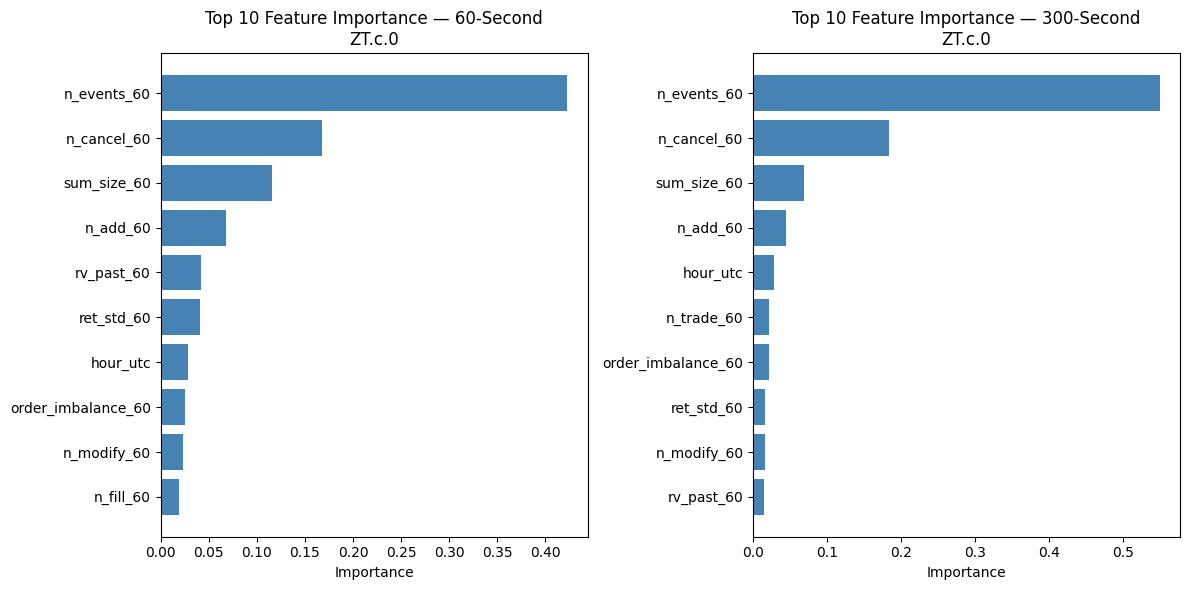

In [ ]:
# choose the symbol for each horizon - we will look at best performer for each time-horizon
symbol_60 = best_reg_symbol_60
symbol_300 = best_reg_symbol_300

# get the stored best models
model_60 = best_reg_models_by_symbol_60[symbol_60]
model_300 = best_reg_models_by_symbol_300[symbol_300]

# build feature importance tables using feature_cols
importance_60 = pd.DataFrame({"feature": feature_cols, "importance": model_60.feature_importances_}).sort_values("importance", ascending=False)

importance_300 = pd.DataFrame({"feature": feature_cols, "importance": model_300.feature_importances_}).sort_values("importance", ascending=False)

# keep top 10 features
top_10_60 = importance_60.head(10).sort_values("importance", ascending=True)
top_10_300 = importance_300.head(10).sort_values("importance", ascending=True)

# plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].barh(top_10_60["feature"], top_10_60["importance"], color="steelblue")
axes[0].set_title(f"Top 10 Feature Importance — 60-Second\n{symbol_60}")
axes[0].set_xlabel("Importance")

axes[1].barh(top_10_300["feature"], top_10_300["importance"], color="steelblue")
axes[1].set_title(f"Top 10 Feature Importance — 300-Second\n{symbol_300}")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

# Regressor feature importance for ZT.c.0

In both horizons, **`n_events_60`** is the most important feature by a wide margin.
- This suggests that overall recent market activity is a major signal for predicting future volatility levels.

**`n_cancel_60`** is also important in both models.
- This suggests cancellation activity may carry useful information about short-term market uncertainty.

**`sum_size_60`** also matters in both horizons.
- This suggests total recent order size adds information beyond simple event counts.

In the **60-second** regressor, recent volatility features such as **`rv_past_60`** and **`ret_std_60`** still play an important role.

In the **300-second** regressor, those features matter less, while activity-based features matter more clearly.

Overall takeaway:
  - both regressors rely most on recent order-flow activity
  - the 60-second model still uses recent volatility information
  - the 300-second model appears to depend more on the broader recent market state

# XGBoost Models for Volatility Forecasting Conclusion

Across both **classification** and **regression**, the results point in the same direction.
- Recent volatility was a useful baseline, but the broader **MBO microstructure feature set** usually improved performance.

At the **shorter 60-second horizon**, the gains were real but modest.
- This suggests that recent realized volatility already contains a lot of near-term signal.
- However, the feature set still helped, especially for spike detection.

At the **longer 300-second horizon**, the gains were much larger.
- This suggests that recent volatility alone becomes a weaker predictor as the forecast window gets longer.
- Rolling activity, imbalance, trade, and return-dispersion features appear to add much more useful information.

The classifier and regressor results tell a consistent story:
  - microstructure features helped at the **shorter 60-second horizon**
  - microstructure features helped more clearly at the **longer 300-second horizon**

Overall takeaway:
  - recent market activity did help predict **future realized volatility**
  - the predictive signal was strongest at the **300-second horizon**
  - recent microstructure features contained useful predictive signal beyond recent volatility alone


# Not All Contracts Are Equal

- Model performance was strongest for the Treasury contracts, especially **ZF.c.0**, **ZN.c.0**, and **ZT.c.0**.
- Performance was weaker for some of the less liquid contracts, especially **6E.c.0**.

This does not appear to be a sample-size issue, but rather fits the EDA story.
- The Treasury contracts showed denser and more consistent market activity, so the rolling microstructure features likely contained stronger signal.
- In contrast, contracts with sparser or less stable order flow likely produced noisier activity features.

- The **6E.c.0** results were especially weak.
- One likely reason is that its test period had a much lower spike rate than the other symbols.
- That made both spike classification and future volatility prediction harder.

Overall takeaway:
  - predictability was not the same across contracts
  - the Treasury contracts appeared to provide the clearest microstructure signal
  - thinner contracts were harder to forecast

# Stationarity concerns

Financial volatility is not fully stationary.
- Volatility levels and spike rates can change over time.

Our pipeline uses several ideas from lecture to make the problem more stable:
  - **Transformation:** the regressor uses `log1p(...)` on the target
  - **Aggregation:** raw MBO events are grouped into 1-second buckets
  - **Smoothing:** many inputs are rolling 60-second features like `rv_past_60` and `n_events_60`
  - **Differencing:** volatility is built from log returns

We do not do full seasonal decomposition.
- Instead, we capture intraday patterns with `hour_utc`.

Overall takeaway:
  - the market is not fully stationary
  - the modeling pipeline makes the features more stable
  - a chronological train/validation/test split is important